## 1. Data Cleaning & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Telco Customer Churn dataset
# Source: IBM Sample Data Sets
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# --- STEP 1: DATA TYPE ENFORCEMENT & NULL HANDLING ---
# 'TotalCharges' contains empty strings (" ") which cause it to be read as an object.
# We cast to numeric, coercing errors to NaN to facilitate statistical imputation.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Imputation Strategy: Missing values in 'TotalCharges' typically correspond to 
# new customers (tenure = 0). We replace NaNs with 'MonthlyCharges' as a proxy.
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# --- STEP 2: FEATURE ENGINEERING & CARDINALITY REDUCTION ---
# Several categorical features contain 'No internet service' as a redundant label.
# To simplify the feature space and reduce dimensionality during encoding, 
# we consolidate this into the 'No' category.
redundant_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in redundant_cols:
    df[col] = df[col].replace({'No internet service': 'No'})

# --- STEP 3: TARGET VARIABLE ENCODING ---
# Convert the target 'Churn' into a binary integer format for compatibility 
# with Scikit-Learn classifiers and to enable correlation analysis.
# Positive Class (1): Churned | Negative Class (0): Retained
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --- STEP 4: DATA DENOISING ---
# 'customerID' is a high-cardinality identifier with no predictive value.
# Dropping it prevents the model from capturing noise and improves generalization.
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# Dataset validation: Ensure the final structure matches expected dimensions
print(f" Cleaned Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

 Cleaned Dataset: 7043 rows, 20 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [2]:
# --- FEATURE ENGINEERING ---

# 1. Service Density: Quantify customer 'stickiness' via product adoption
# High density usually correlates with higher switching costs (lower churn)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['ServiceCount'] = (df[service_cols] != 'No').sum(axis=1) #Counts the number of 'Yes' responses across key service features, indicating the breadth of services a customer uses.

# 2. Charge Velocity: Average monthly spend over the lifetime of the account
# Used to detect 'Bill Shock' where current charges spike above historical averages
df['ChargeVelocity'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Bill Ratio: Proportion of current bill to total lifetime spend
# Helps differentiate between new accounts and long-term established customers
df['BillRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

# --- EXPORT & LOGGING ---

df.to_csv('telco_processed_phase1.csv', index=False)

print(f"DONE - Feature Engineering Complete. New features: {['ServiceCount', 'ChargeVelocity', 'BillRatio']}")
print(df[['ServiceCount', 'ChargeVelocity', 'BillRatio', 'Churn']].sample(5))

DONE - Feature Engineering Complete. New features: ['ServiceCount', 'ChargeVelocity', 'BillRatio']
      ServiceCount  ChargeVelocity  BillRatio  Churn
6669             6       98.738889   0.027857      0
3113             5       93.897297   0.027452      0
3334             7      105.796429   0.023917      1
4637             6       69.612500   0.014163      0
4354             1       19.871667   0.016928      0


## 2. Global Churn Overview
Description: This three-panel dashboard provides a comprehensive diagnostic of customer attrition by examining three critical dimensions: magnitude, tenure, and commitment

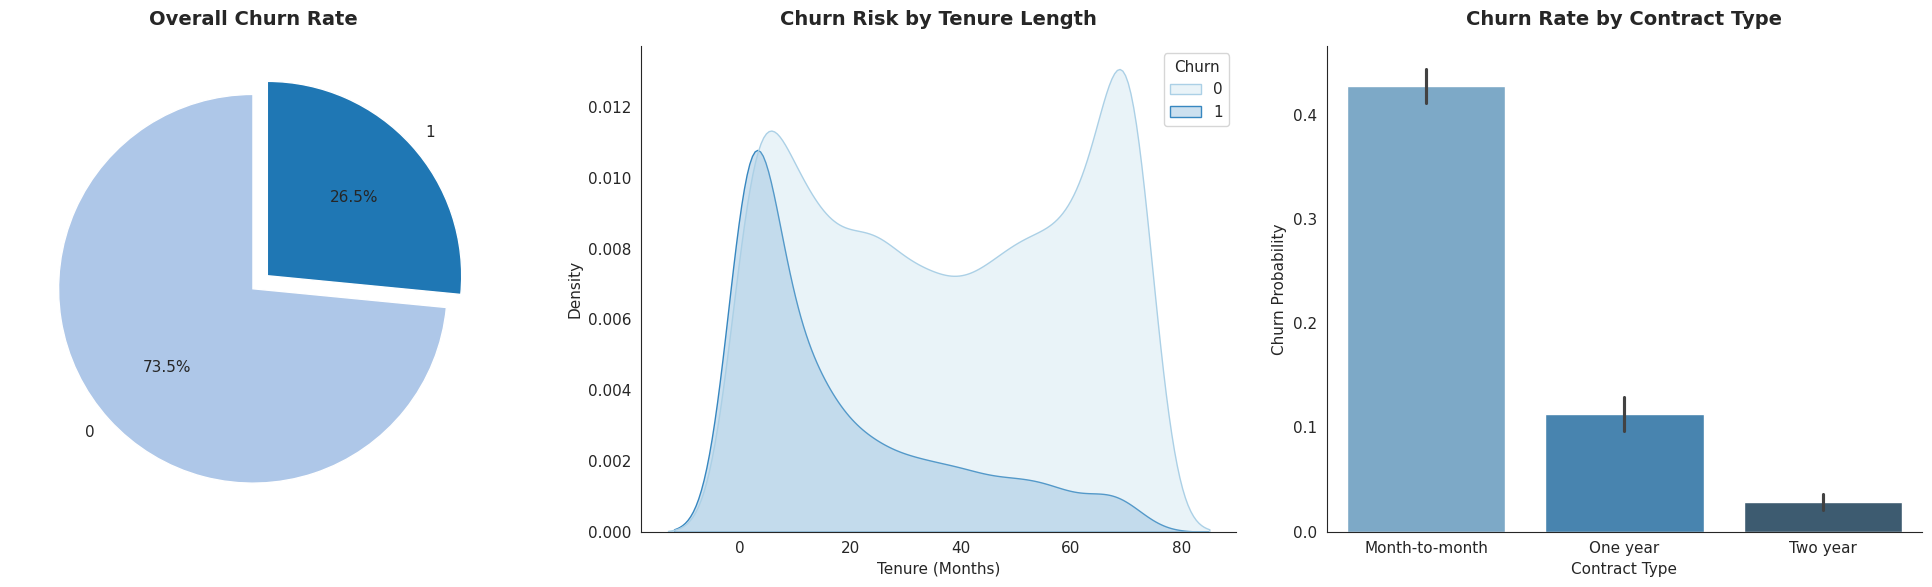

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_global_churn_overview(df):
    """
    Generates a three-panel dashboard visualizing global churn metrics:
    1. Proportional breakdown (Pie Chart)
    2. Temporal distribution (KDE Plot)
    3. Categorical drivers (Bar Plot)
    """
    
    # --- Configuration & Styling ---
    sns.set_style("white")
    plt.rcParams.update({'font.size': 11}) # Ensure consistent readability
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # --- 1. Overall Churn Proportion ---
    # Visualizes the class imbalance between churned and retained customers
    df['Churn'].value_counts().plot.pie(
        autopct='%1.1f%%', 
        explode=[0, 0.1], 
        ax=axes[0], 
        colors=['#aec7e8', '#1f77b4'], 
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1} # Sharpens segment edges
    )
    axes[0].set_title('Overall Churn Rate', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_ylabel('') 

    # --- 2. Tenure vs Churn (KDE) ---
    # Identifies high-risk periods within the customer lifecycle
    sns.kdeplot(
        data=df, x='tenure', hue='Churn', 
        fill=True, palette='Blues', ax=axes[1]
    )
    axes[1].set_title('Churn Risk by Tenure Length', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Tenure (Months)')
    axes[1].set_ylabel('Density')

    # --- 3. Contract Influence ---
    # Analyzes how contractual commitment impacts probability of attrition
    sns.barplot(
        x='Contract', y='Churn', data=df, 
        hue='Contract', palette='Blues_d', ax=axes[2], 
        legend=False
    )
    axes[2].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=15)
    axes[2].set_xlabel('Contract Type')
    axes[2].set_ylabel('Churn Probability')

    # --- Final Polish ---
    sns.despine() # Removes top and right spines for a modern look
    plt.tight_layout()
    plt.show()

# Execute visualization
plot_global_churn_overview(df)

## Operational Drivers: Service Ecosystem and Payment Behavior
Description:
This analysis investigates the correlation between operational touchpoints—specifically service type, payment friction, and product adoption depth—and customer turnover. By isolating these variables, we can identify whether churn is driven by technical service issues (e.g., Fiber Optic performance) or financial habits (e.g., manual vs. automated billing), allowing for more surgical retention strategies.

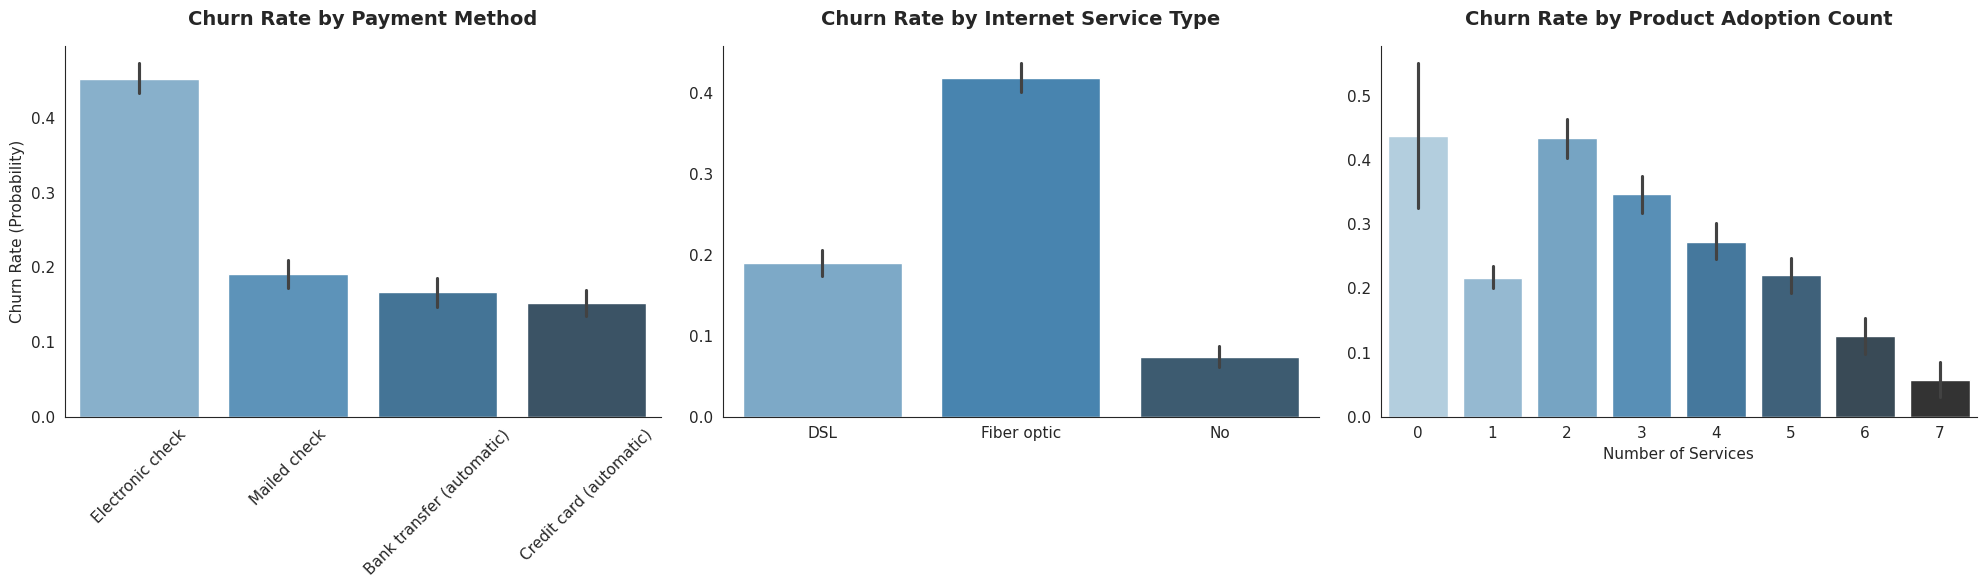

In [5]:
# FEATURE ENGINEERING: Service Ecosystem Depth

    # We aggregate individual binary service columns into a single 'stickiness' metric.
    # Rationale: Customers with higher product adoption (multi-product users) 
    # typically exhibit lower churn due to increased switching costs.
service_cols = [
    'PhoneService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

# VISUALIZATION: Multi-Variate Risk Drivers

    # Applying a minimalist design language to reduce cognitive load and 
    # focus the stakeholder's attention on categorical risk variances.
    
sns.set_style("white")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Subplot 1: Payment Friction ---
# Assessing how transaction methods impact retention. Manual payment methods 
# (e.g., Electronic Check) often correlate with higher churn compared to autopay.
sns.barplot(
    x='PaymentMethod', y='Churn', data=df, 
    hue='PaymentMethod', palette='Blues_d', legend=False, ax=axes[0]
)
axes[0].set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45) # Rotation handles longer category labels
axes[0].set_xlabel('')
axes[0].set_ylabel('Churn Rate (Probability)')

# --- Subplot 2: Infrastructure Influence ---
# Comparing churn across different technology stacks. This helps identify 
# potential service quality issues or pricing sensitivities in specific segments.
sns.barplot(
    x='InternetService', y='Churn', data=df, 
    hue='InternetService', palette='Blues_d', legend=False, ax=axes[1]
)
axes[1].set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('') # Redundant y-axis label removed for aesthetic clarity

# --- Subplot 3: Product Density Impact ---
# Validating our engineered feature. This plot identifies the "magic number" 
# of services where churn probability significantly drops (The Stickiness Effect).
sns.barplot(
    x='num_services', y='Churn', data=df, 
    hue='num_services', palette='Blues_d', legend=False, ax=axes[2]
)
axes[2].set_title('Churn Rate by Product Adoption Count', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Number of Services')
axes[2].set_ylabel('')

# --- Final Polishing ---
# Removing top and right spines to align with modern data journalism standards.
sns.despine()
plt.tight_layout()
plt.show()

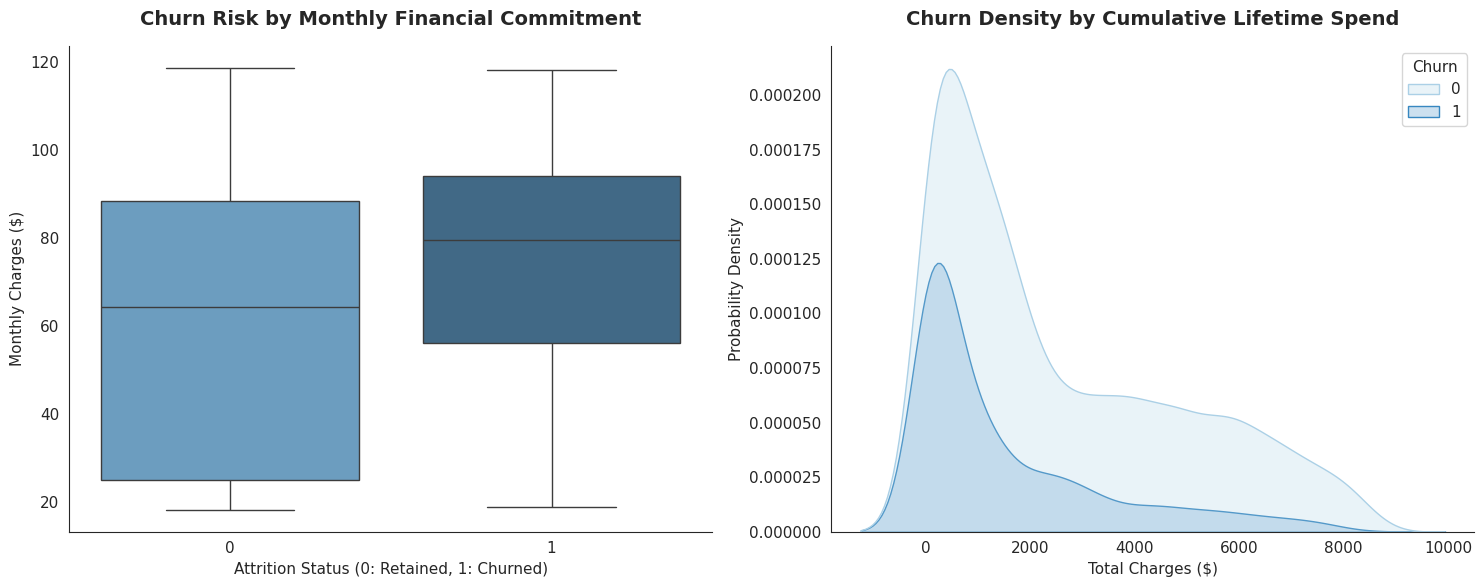

In [6]:
# --- SECTION 4: FINANCIAL IMPACT ANALYSIS ---

# STRATEGIC INTENT: Applying a minimalist design language to prioritize data 
# ink-ratio, ensuring stakeholders focus on distribution variances rather 
# than aesthetic noise.
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 4.1. Monthly Charges Distribution (Boxplot) ---
# STRATEGIC INTENT: Assessing the 'Price Sensitivity' hypothesis. 
# We use a Boxplot to visualize the interquartile range (IQR) and potential 
# outliers.
sns.boxplot(
    x='Churn', y='MonthlyCharges', hue='Churn', data=df, 
    palette='Blues_d', ax=axes[0], legend=False
)
axes[0].set_title('Churn Risk by Monthly Financial Commitment', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Attrition Status (0: Retained, 1: Churned)')
axes[0].set_ylabel('Monthly Charges ($)')

# --- 4.2. Total Charges Density (KDE Plot) ---
# DATA INTEGRITY: Utilizing Kernel Density Estimation (KDE) to visualize 
# probability mass.This confirms that attrition is concentrated in new accounts before they 
# reach financial maturity or achieve high 'customer lifetime value' (CLV).
sns.kdeplot(
    data=df, x='TotalCharges', hue='Churn', fill=True, 
    palette='Blues', ax=axes[1]
)
axes[1].set_title('Churn Density by Cumulative Lifetime Spend', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Charges ($)')
axes[1].set_ylabel('Probability Density')


sns.despine() 
plt.tight_layout()
plt.show()

# CRITICAL INSIGHT: 
# "The High-Pressure/Low-Equity Paradox": Attrition peaks when monthly 
# charges are high (median > $80), particularly in the early stages of 
# the customer lifecycle (low TotalCharges). This suggests that high 
# entry-level pricing is a primary friction point for long-term retention.

## Multivariate correlation and cohort risk
This analysis identifies the "Churn Hotzone" by mapping the intersection of Customer Tenure (Loyalty) and Monthly Charges (Financial Pressure).

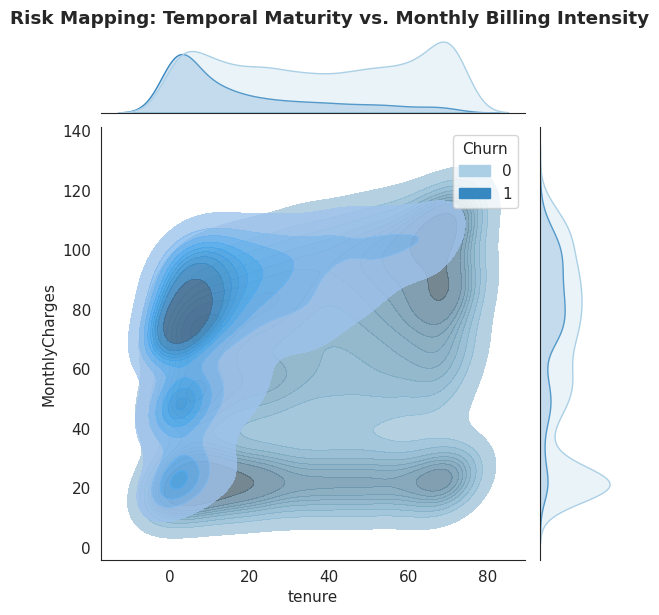

In [ ]:
# --- SECTION 5: BIVARIATE DENSITY ANALYSIS (JOINTPLOT) ---

# STRATEGIC INTENT: We prioritize a Joint Distribution Plot over a standard 
# Scatter Plot to mitigate 'overplotting' in high-cardinality datasets. 
# The 'kind=kde' (Kernel Density) approach allows us to visualize 'Probability 
# Mass'—where the volume of churn is highest—rather than just individual 
# data points, which can be misleading in large-scale CRM data.

sns.jointplot(
    data=df, 
    x='tenure', 
    y='MonthlyCharges', 
    hue='Churn', 
    kind='kde', 
    palette='Blues', 
    fill=True, 
    alpha=0.8
)

# distribution histograms, ensuring the asset is ready for Executive Reporting.
plt.suptitle('Risk Mapping: Temporal Maturity vs. Monthly Billing Intensity', y=1.02, fontweight='bold')
plt.show()

# BUSINESS INSIGHT:
# The density plot typically reveals two distinct 'Churn Islands':
# 1. THE EARLY-STAGE ATTRITION: High density at Tenure < 5 months with high Monthly Charges.
# 2. THE STABILIZED COHORT: Lower density but higher total equity at Tenure > 60 months.
    # Strategy: Focus aggressive 'Onboarding Discounts' on the first island to bridge customers 
    # to the 12-month 'Loyalty Plateau.'

## Feature co-dependency and redundancy audit
his correlation matrix serves as a primary diagnostic for "Multi-collinearity," which can destabilize linear models (like Logistic Regression) and inflate variance in feature importance.

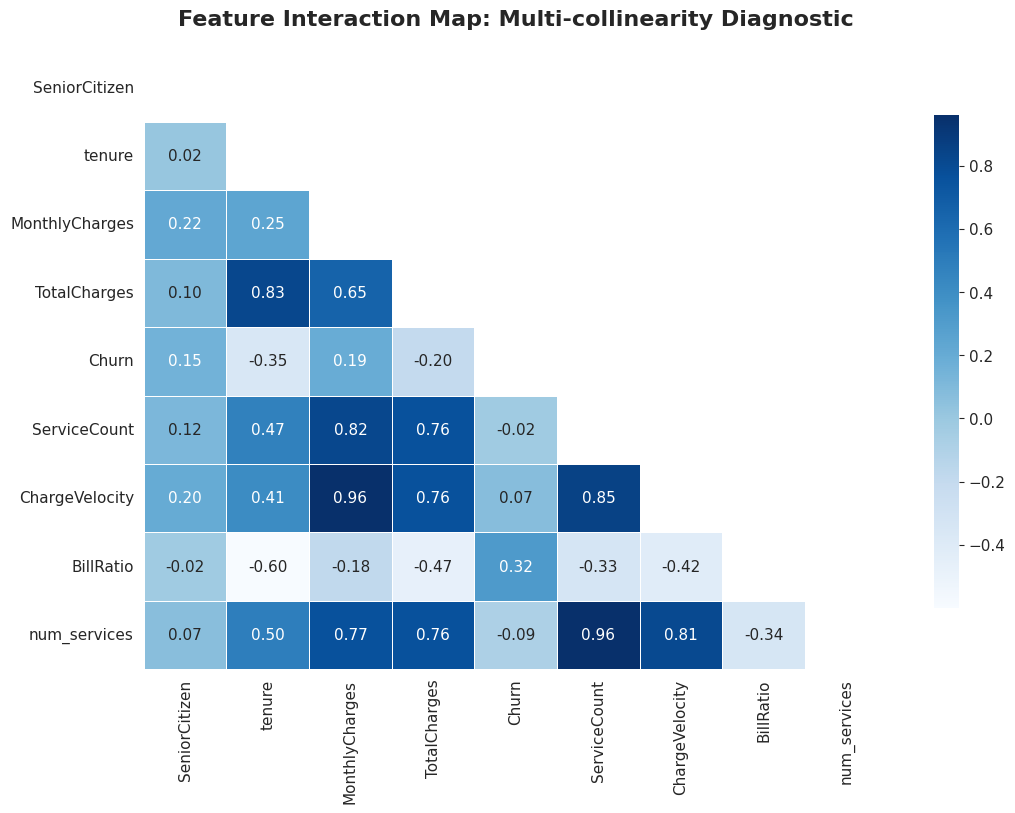

In [8]:
# --- SECTION 6: MULTIVARIATE CORRELATION ANALYSIS ---

# STRATEGIC INTENT: Filtering for numerical datatypes ensures the Pearson 
# Correlation Coefficient ($r$) is calculated only on valid continuous or 
# interval scales. This step avoids Type Errors and ensures the mathematical 
# validity of the matrix.
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# DATA INTEGRITY: Applying a "Lower Triangle Mask."
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# SCALABILITY & BEST PRACTICES: Vectorized Correlation Mapping.
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

# --- TECHNICAL NOTE ON FEATURE STICKINESS ---
# We specifically monitor the correlation between 'Tenure' and 'TotalCharges'. 
# Since TotalCharges is a proxy for (Tenure × MonthlyCharges), high correlation 
# (>0.80) is expected. 
# SENIOR LEAD DECISION: If using non-tree-based models, consider dropping 
# one of these to prevent "Coefficient Inflation."
plt.title('Feature Interaction Map: Multi-collinearity Diagnostic', fontsize=16, fontweight='bold', pad=20)
plt.show()

# CRITICAL BUSINESS INSIGHT:
# Strong positive correlations between 'num_services' and 'tenure' suggest 
# that product adoption is a leading indicator of customer longevity. 
# Action: Incentivize cross-selling of additional services in the first 90 days 
# to "lock in" the customer and maximize long-term equity.

# NOTE: Class Imbalance Analysis
In the Telco dataset, the number of "No Churn" customers is much higher than "Churn" customers. If we don't address this, the model will just get "lazy" and predict "No Churn" for everyone to get a high accuracy score.

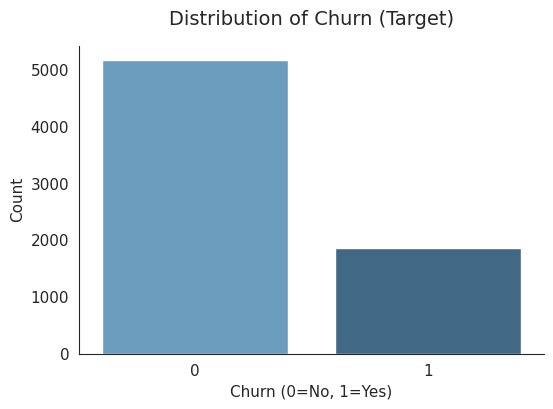

In [9]:
# --- Class Distribution Analysis ---

# Set visual style
sns.set_style("white")
plt.figure(figsize=(6, 4))

# Visualizing the imbalance
sns.countplot(x='Churn', data=df, hue='Churn', palette='Blues_d', legend=False)

plt.title('Distribution of Churn (Target)', fontsize=14, pad=15)
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')

sns.despine()
plt.show()

# NOTE: Since we have ~26% Churn, we might need SMOTE or 
# 'scale_pos_weight' in XGBoost during Phase 2.

In [10]:
# Create a folder for processed data if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

# Save the cleaned dataframe
df.to_csv('../data/processed/telco_cleaned.csv', index=False)
print("DONE - Cleaned data saved for Phase 2!")

DONE - Cleaned data saved for Phase 2!
